In [26]:
%load_ext autoreload
%autoreload 2

# Get parent root directory and add to sys.path
import sys, os
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
from src.rocket import Rocket
from src.pos_rocket_vis import *
from nmpc_land import NmpcCtrl
import numpy as np

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir,"rocket.yaml")

# Rocket setup
Ts = 1 / 20
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
rocket.mass = 1.7 # Do not change!!!

# Visualization setup
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1

In [28]:
sim_time = 4.0 # simulation length in seconds
x0 = np.array([
    0, 0, 0, # w
    0, 0, np.deg2rad(30), # phi
    0, 0, 0, # v
    3, 2, 10, # p
])
xt = np.array([
    0, 0, 0, # w
    0, 0, 0, # phi
    0, 0, 0, # v
    1, 0, 3, # p
])
# xs, us = rocket.trim(xt)
# print("Linearization around a steady state:")
# print("xt = ", xt)
# print("xs = ", xs)
# print("us = ", us)

H = 3.0 # horizon time 
# nmpc = NmpcCtrl(rocket, H, xs, us)
nmpc = NmpcCtrl(rocket, H)
nmpc._setup_controller(xt)

In [29]:
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol = rocket.simulate_land(nmpc, sim_time, H, x0)

Simulating time 0.00
Simulating time 1.00
Simulating time 2.00
Simulating time 3.00


In [30]:
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol)

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=79, step=2), IntSlider(value=0,…

{'fig': <Figure size 640x480 with 16 Axes>,
 'axes': [<Axes: ylabel='inputs'>,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: title={'center': 'Subsystem Y'}>,
  <Axes: title={'center': 'Subsystem X'}, ylabel='$\\omega_{\\phi\\theta\\psi}$ (deg/s)'>,
  <Axes: title={'center': 'Subsystem Z'}>,
  <Axes: >,
  <Axes: ylabel='$\\phi\\theta\\psi$ (deg)'>,
  <Axes: title={'center': 'Subsystem Roll'}>,
  <Axes: ylabel='$v_{\\text{ENU}}$ (m/s)'>,
  <Axes: >,
  <Axes: >,
  <Axes: ylabel='$\\text{pos}_{\\text{ENU}}$ (m)'>,
  <Axes: >,
  <Axes: >],
 'plotter': <pyvista.plotting.plotter.Plotter at 0x21c95776ad0>,
 'scene_objects': {'rocket_actor': Actor (0x21c956af760)
    Center:                     (3.060356440456486, 1.7874210169066358, 10.5884845)
    Pickable:                   True
    Position:                   (0.0, 0.0, 0.0)
    Scale:                      (1.0, 1.0, 1.0)
    Visible:                    True
    X Bounds                    1.998E+00, 4.122E+00
    Y Bounds                  

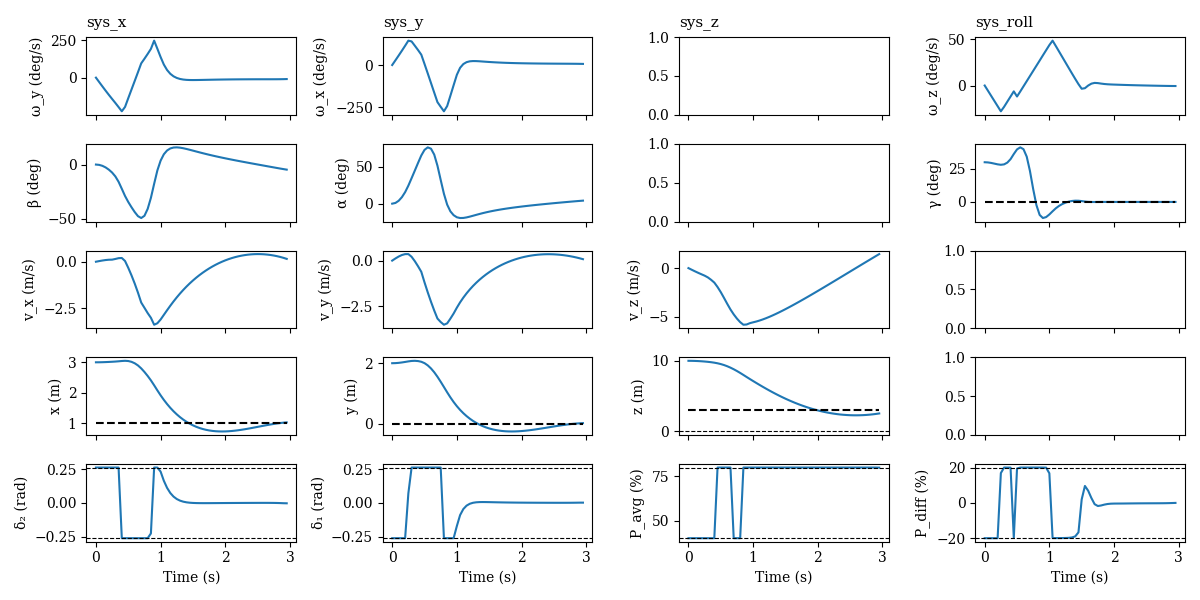

In [31]:
plot_static_states_inputs(t_ol[:-1, 0], x_ol[:,:-1, 0], u_ol[:, :, 0], xt)

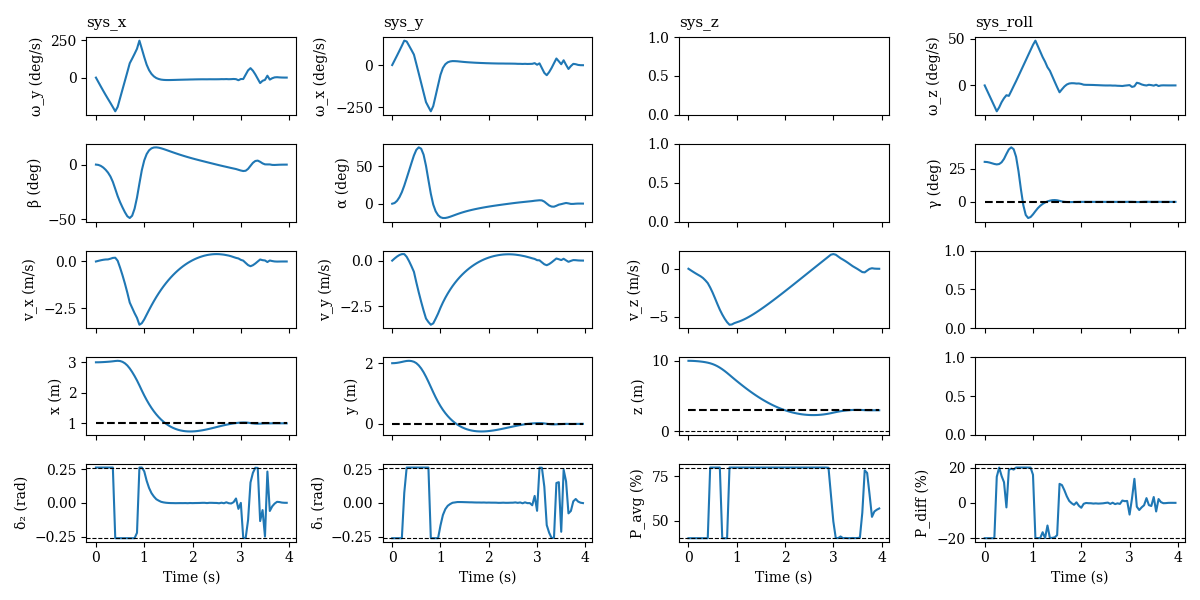

In [32]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xt)